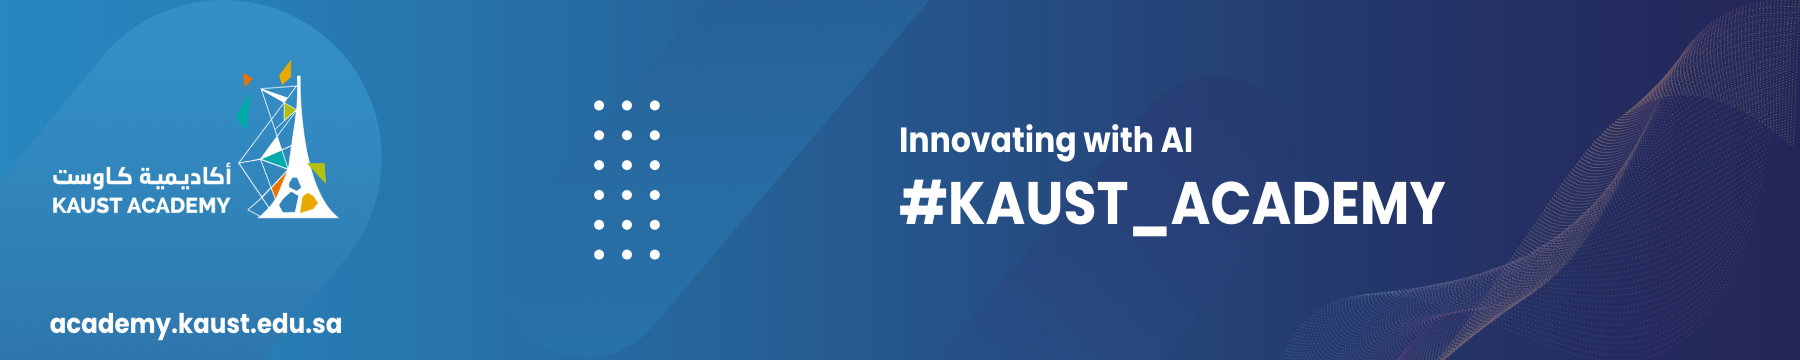

# Lab 2: Q-Learning 

- Manual policies become difficult for larger environments.
- The agent needs to learn which actions are useful through experience.



### 1.Q-Learning

Q-learning is a model-free reinforcement learning algorithm.

It learns the quality of taking action $a$ in state $s$.

This quality is represented by:

$$
Q(s,a)
$$

The agent updates its Q-values using experience from the environment.

The Q-learning update equation is:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r
+
\gamma \max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

where:

| Symbol | Meaning |
|---|---|
| $s$ | Current state |
| $a$ | Current action |
| $r$ | Reward received |
| $s'$ | Next state |
| $a'$ | Possible action in the next state |
| $\alpha$ | Learning rate |
| $\gamma$ | Discount factor |
| $Q(s,a)$ | Current Q-value |
| $\max_{a'}Q(s',a')$ | Best Q-value available in the next state |




In [29]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

state, info = env.reset()

### 2. Create the Q-Table

A Q-table stores the quality of every possible action in every state.

- Rows represent states.
- Columns represent actions.
- Each cell stores $Q(s,a)$.


In [4]:
number_of_states = env.observation_space.n
number_of_actions = env.action_space.n

q_table = np.zeros(
    (number_of_states, number_of_actions)
)

print("Q-table shape:", q_table.shape)
print(q_table)

Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### 3. Exploration and Exploitation

At the beginning, all Q-values are zero, so the agent does not know which action is best.

The agent must balance two behaviors:

- **Exploration:** try a random action to discover new possibilities.
- **Exploitation:** select the action with the highest known Q-value.

The parameter $\epsilon$ controls exploration.

$$
A_t =
\begin{cases}
\text{Random action}, & \text{with probability } \epsilon \\
\arg\max_a Q(S_t,a), & \text{otherwise}
\end{cases}
$$

A high value of $\epsilon$ means more exploration.

A low value of $\epsilon$ means more exploitation.

In [5]:
epsilon = 1.0

def choose_action(state, q_table, epsilon):
    random_number = np.random.random()

    if random_number < epsilon:
        action = env.action_space.sample()
        decision = "Explore"
    else:
        action = np.argmax(q_table[state])
        decision = "Exploit"

    return action, decision

### 4. Bellman Equation & Q-Learning Update

After the agent takes an action, it receives:

- A reward $r$
- A next state $s'$

The Bellman optimality equation connects the current state-action value to the immediate reward and the best future value:

$$
Q^*(s,a)
=
r+\gamma\max_{a'}Q^*(s',a')
$$

During training, the optimal value $Q^*$ is unknown. Therefore, Q-learning uses the current Q-table to calculate a target:

$$
\text{TD Target}
=
r+\gamma\max_{a'}Q(s',a')
$$

The difference between the target and the current Q-value is the **temporal-difference error**:

$$
\delta
=
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
$$

The Q-value is then updated using:

$$
Q(s,a)
\leftarrow
Q(s,a)+\alpha\delta
$$

Combining the equations gives:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
\right]
$$



In [14]:
episodes = 5000
learning_rate = 0.1
gamma = 0.9

epsilon = 1.0
minimum_epsilon = 0.01
epsilon_decay = 0.001

episode_rewards = []

for episode in range(episodes):
    state, info = env.reset()

    terminated = False
    truncated = False
    total_reward = 0

    while not terminated and not truncated:
        # Exploration or exploitation
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Apply the action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        old_q_value = q_table[state, action]
        best_next_q_value = np.max(q_table[next_state])

        q_table[state, action] = old_q_value + learning_rate * (
            reward
            + gamma * best_next_q_value
            - old_q_value
        )

        state = next_state
        total_reward += reward

    # Reduce exploration gradually
    epsilon = max(
        minimum_epsilon,
        epsilon - epsilon_decay
    )

    episode_rewards.append(total_reward)

print("Training finished")
print("Final epsilon:", epsilon)

Training finished
Final epsilon: 0.01


### 5. Display the Learned Q-Table

After training, the Q-table contains the learned quality of each action in every state.


In [15]:
action_names = [
    "Left",
    "Down",
    "Right",
    "Up"
]

q_table_df = pd.DataFrame(
    q_table,
    columns=action_names
)

q_table_df

,Left,Down,Right,Up
0,0.531346,0.590490,0.477483,0.531207
1,0.531272,0.000000,0.227239,0.339834
2,0.077842,0.467017,0.006967,0.132359
3,0.025438,0.000000,0.001591,0.001204
4,0.590360,0.656100,0.000000,0.531400
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.723820,0.000000,0.139181
7,0.000000,0.000000,0.000000,0.000000
8,0.655886,0.000000,0.729000,0.590430
9,0.655023,0.810000,0.809362,0.000000


### 7. Extract the Learned Policy

After training, the agent selects the action with the highest Q-value in each state.

$$
\pi(s)=\arg\max_a Q(s,a)
$$

The learned policy converts the Q-table into one best action for every state.

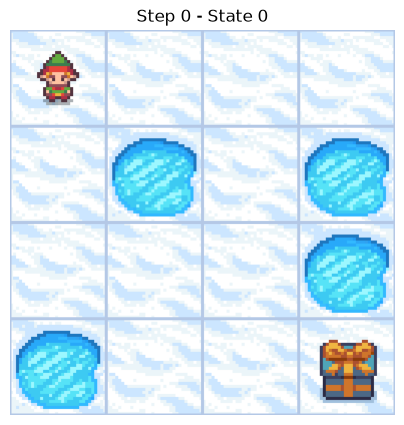

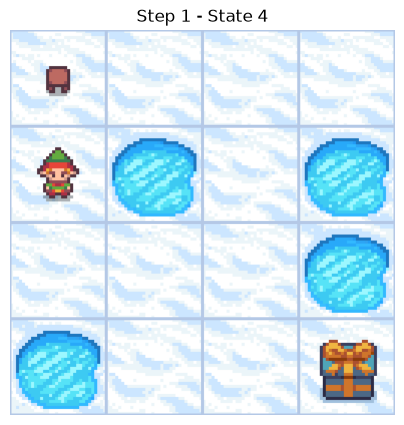

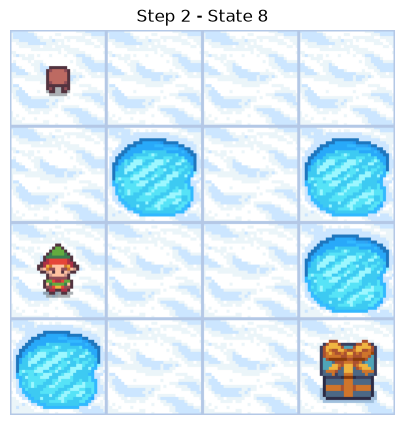

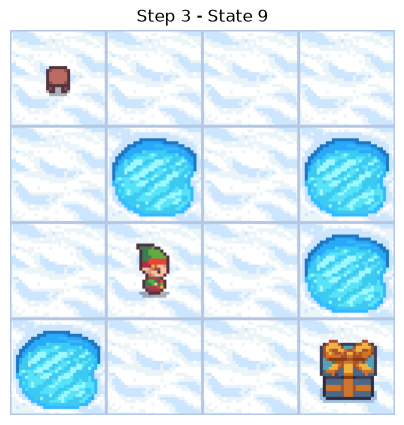

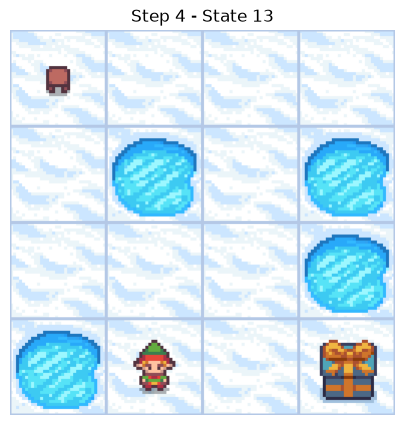

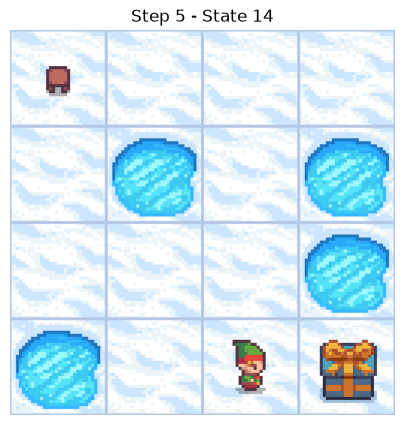

Final reward: 1


In [ ]:


render_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

state, info = render_env.reset()

terminated = False
truncated = False
step = 0

while not terminated and not truncated:
    frame = render_env.render()

    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Step {step} - State {state}")
    plt.show()

    # Choose the best learned action
    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = (
        render_env.step(action)
    )

    step += 1

print("Final reward:", reward)

render_env.close()

### 8. Evaluate the Trained Agent

After training, we evaluate the agent without exploration.

The agent always selects the action with the highest Q-value:

$$
A_t=\arg\max_a Q(S_t,a)
$$

The success rate measures how often the agent reaches the goal.

In [26]:
evaluation_episodes = 100
successes = 0

for episode in range(evaluation_episodes):
    state, info = env.reset(seed=episode)

    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Always exploit the learned Q-table
        action = np.argmax(q_table[state])

        state, reward, terminated, truncated, info = env.step(action)

        if reward == 1:
            successes += 1

success_rate = successes / evaluation_episodes

print("Successful episodes:", successes, "/", evaluation_episodes)
print("Success rate:", success_rate * 100, "%")

Successful episodes: 100 / 100
Success rate: 100.0 %


### Exercise
1. Change is_slippery from False to True.
2. Train a new Q-table for the slippery environment.
3. Test the learned policy and calculate the success rate.

Contributed by : Lama Ayash